# Estudio de parámetros de Sarsa Semigradiente

**Descripción**: En este experimento se comparan distintos números de pasos máximos por episodio para Sarsa Semigradiente, y diferente número de tilings. El análisis se realiza sobre el entorno Mountain Car de Gymnasium. En este entorno, el agente debe elegir entre acelerar hacia la izquierda, no acelerar, o acelerar hacia la derecha. La recompensa es -1 por cada paso, y 100 por tocar la bandera, que se encuentra al final de una colina. Cuando toca la bandera, finaliza el episodio. También puede finalizar porque se han dado el número de pasos máximos.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

This software is licensed under the GNU General Public License v3.0 (GPL-3.0), with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

----

## **1. Preparación del Entorno**

Para la preparación del entorno, en primer lugar se instalan las librerías necesarias para utilizar el entorno `gymnasium`.

A continuación, se importan las librerías necesarias para la ejecución del notebook.

In [ ]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG

from src.tilings.tiling import TileCodingEnv

from src.ploting import *

Una vez importadas las librerías, se configuran las semillas para los números aleatorios con el fin de garantizar la reproducibilidad de los resultados.

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cuda


A continuación, se declaran las siguientes constantes:

- El directorio donde se almacenan los vídeos generados
- El nombre del entorno (MountainCar)
- El tipo de renderizado del entorno

In [3]:
#@title Definición de constantes
video_folder = "./videos"
name = 'MountainCar-v0'
render = "rgb_array"

Por último, se crean las instancias del entorno FrozenLake en sus versiones con máximo 200 pasos, máximo 500 pasos, y máximo 1000 pasos.

In [4]:
#@title Importamos el entorno
env_200 = gym.make(name, render_mode=render, max_episode_steps=200)
env_500 = gym.make(name, render_mode=render, max_episode_steps=500)
env_1000 = gym.make(name, render_mode=render, max_episode_steps=1000)

A continuación, se crea el entorno con discretización del espacio mediante tilings de 20x20. Se crea un espacio con 2 tilings, otro con 4, y otro con 10.

In [5]:
#@title Se generan tilings con 20x20 intervalos, y entornos para 2, 4, y 10 tilings

# Parámetros para crear los environments
low = env_500.observation_space.low
high = env_500.observation_space.high
bins = np.array([20, 20])

# 200 pasos
# Environment 2
tcenv_2_200 = TileCodingEnv(env_200, bins=bins, low=low, high=high, seed=seed, n=2)

# Environment 4
tcenv_4_200 = TileCodingEnv(env_200, bins=bins, low=low, high=high, seed=seed, n=4)

# Environment 10
tcenv_10_200 = TileCodingEnv(env_200, bins=bins, low=low, high=high, seed=seed, n=10)

# 500 pasos
# Environment 2
tcenv_2_500 = TileCodingEnv(env_500, bins=bins, low=low, high=high, seed=seed, n=2)

# Environment 4
tcenv_4_500 = TileCodingEnv(env_500, bins=bins, low=low, high=high, seed=seed, n=4)

# Environment 10
tcenv_10_500 = TileCodingEnv(env_500, bins=bins, low=low, high=high, seed=seed, n=10)

# 1000 pasos
# Environment 2
tcenv_2_1000 = TileCodingEnv(env_1000, bins=bins, low=low, high=high, seed=seed, n=2)

# Environment 4
tcenv_4_1000 = TileCodingEnv(env_1000, bins=bins, low=low, high=high, seed=seed, n=4)

# Environment 10
tcenv_10_1000 = TileCodingEnv(env_1000, bins=bins, low=low, high=high, seed=seed, n=10)

## **2. Implementación de Sarsa Semigradiente**

A continuación, se implementa el método para la iteración en Sarsa Semigradiente

In [6]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def diferencia_temporal(tcenv, agente, num_episodes=5000):
    stats = 0.0
    list_stats = []
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = tcenv.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        action = agente.get_action(state, t)
        while not done:
            new_state, reward, done, truncated, _ = tcenv.step(action)
            done = done or truncated
            new_action = agente.get_action(new_state, t)
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            agente.update(state, action, reward, new_state, new_action, done)
            result_sum += reward
            state = new_state
            action = new_action

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/(t+1):.2f}, Epsilon: {agente.epsilon:.3f}, Alpha: {agente.alpha:.3f}")

    return list_stats, all_episode_lengths


Se definen las constantes para la experimentación

In [7]:
#@title Constantes para la experimentación
FACTOR_DESCUENTO = 0.99
EPSILON_INICIAL = 0.4 # No se usa porque se usa decaimiento
DECAIMIENTO = True
NUM_EPISODIOS = 4000
DECAY_RATE = 200

A continuación, se crea una función para hacer cada experimento con varias semillas.

In [8]:
def entrenar_agente(env):
    seeds=[1, 12, 123, 1234, 12345, 123456]
    longitudes = []
    for seed in seeds:
        agente = AgenteDT_SarsaSG(env, seed, discount_factor=FACTOR_DESCUENTO, epsilon=EPSILON_INICIAL, decay=DECAIMIENTO, num_episodes=NUM_EPISODIOS, decay_rate = DECAY_RATE)

        _, lengths = diferencia_temporal(env, agente=agente, num_episodes=NUM_EPISODIOS)

        longitudes.append(lengths)
    longitudes = np.array(longitudes)
    media_longitudes = longitudes.mean(axis=0)
    std_longitudes = longitudes.std(axis=0)

    return media_longitudes, std_longitudes

A continuación, se crea una función para hacer la gráfica de la media y desviación típica de cada experimento

In [ ]:
def plot_lengths_mean_std(mean_lengths, std_lengths, window_size=50):
    # Crea un array con índices de episodios (0, 1, ..., N-1)
    indices = np.arange(len(mean_lengths))
    # Calcula la media movil de mean_lengths
    moving_avg = np.convolve(mean_lengths, np.ones(window_size)/window_size, mode='valid')
    # Crea la figura
    plt.figure(figsize=(10,5))
    # Dibuja mean_lengths
    plt.plot(indices, mean_lengths, alpha=0.3, label='Media de pasos')
    # Dibuja mean_lengths +- std_lengths
    plt.fill_between(indices,
                     mean_lengths - std_lengths,
                     mean_lengths + std_lengths,
                     alpha=0.2, label='±1 std')
    # Dibuja la media movil
    plt.plot(range(window_size-1, len(mean_lengths)),
             moving_avg, color='red', linewidth=2,
             label=f'Tendencia (media móvil {window_size})')
    # Pone el título de la gráfica y los ejes
    plt.title('Longitud de episodios (media sobre semillas)')
    plt.xlabel('Episodio')
    plt.ylabel('Pasos')
    # Termina de mostrar el gráfico
    plt.legend()
    plt.grid(True)
    plt.show()

## **3. Experimentación**

En esta sección, se lleva a cabo la experimentación con las distintas variantes del algoritmo Sarsa Semigradiente.

### **3.1 Espacio discretizado con 2 tilings**

#### **3.1.1. Máximo de 200 pasos**

En primer lugar, se entrena el algoritmo

In [10]:
# @title Aprendizaje
media_longitudes_sarsa_2_200, std_longitudes_sarsa_2_200 = entrenar_agente(tcenv_2_200)

 11%|█         | 426/4000 [00:02<00:21, 169.67it/s]

Episode: 400, Avg Return: -200.00, Epsilon: 0.400, Alpha: 0.372


 21%|██        | 827/4000 [00:04<00:20, 153.92it/s]

Episode: 800, Avg Return: -200.00, Epsilon: 0.250, Alpha: 0.259


 31%|███       | 1223/4000 [00:07<00:17, 155.16it/s]

...

 81%|████████  | 3229/4000 [00:19<00:04, 191.72it/s]

Episode: 3200, Avg Return: -191.35, Epsilon: 0.062, Alpha: 0.070


 91%|█████████ | 3647/4000 [00:22<00:01, 193.40it/s]

Episode: 3600, Avg Return: -187.04, Epsilon: 0.056, Alpha: 0.207


100%|██████████| 4000/4000 [00:23<00:00, 167.78it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

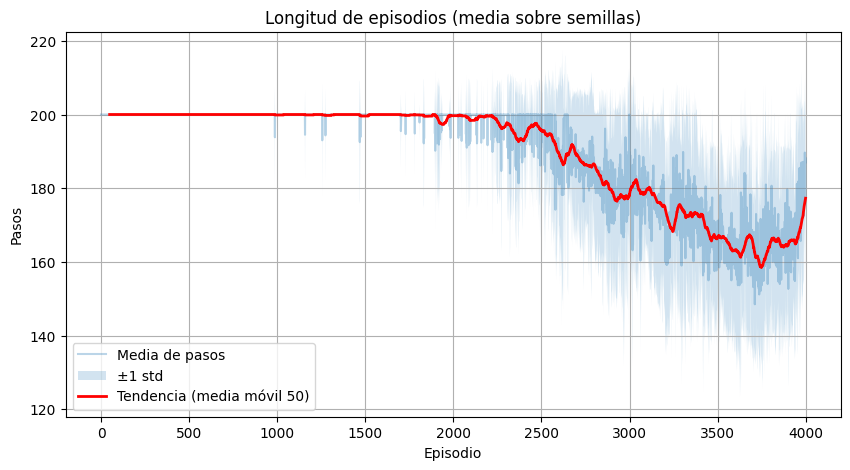

In [11]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_2_200, std_longitudes_sarsa_2_200)

Al inicio del entrenamiento, la longitud media de los episodios se mantiene pegada al límite de 200 pasos, lo que indica que el agente no alcanza la cima.

A partir del episodio 2000 aproximadamente, la tendencia empieza a descender, con una duración menor de cada episodio. Sin embargo, a partir de los 2000 pasos hay bastante variación entre semillas, pero se ve cómo claramente baja de los 200 pasos.

#### **3.1.2. Máximo de 500 pasos**

En primer lugar, se entrena el algoritmo

In [12]:
# @title Aprendizaje
media_longitudes_sarsa_2_500, std_longitudes_sarsa_2_500 = entrenar_agente(tcenv_2_500)

 10%|█         | 411/4000 [00:05<00:48, 74.00it/s]

Episode: 400, Avg Return: -493.99, Epsilon: 0.400, Alpha: 1.000


 21%|██        | 824/4000 [00:10<00:26, 118.91it/s]

Episode: 800, Avg Return: -444.31, Epsilon: 0.250, Alpha: 0.437


 31%|███       | 1230/4000 [00:13<00:15, 177.57it/s]

...

 81%|████████  | 3227/4000 [00:32<00:03, 193.40it/s]

Episode: 3200, Avg Return: -311.93, Epsilon: 0.062, Alpha: 0.019


 91%|█████████ | 3638/4000 [00:34<00:01, 199.78it/s]

Episode: 3600, Avg Return: -294.94, Epsilon: 0.056, Alpha: 0.278


100%|██████████| 4000/4000 [00:36<00:00, 110.59it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

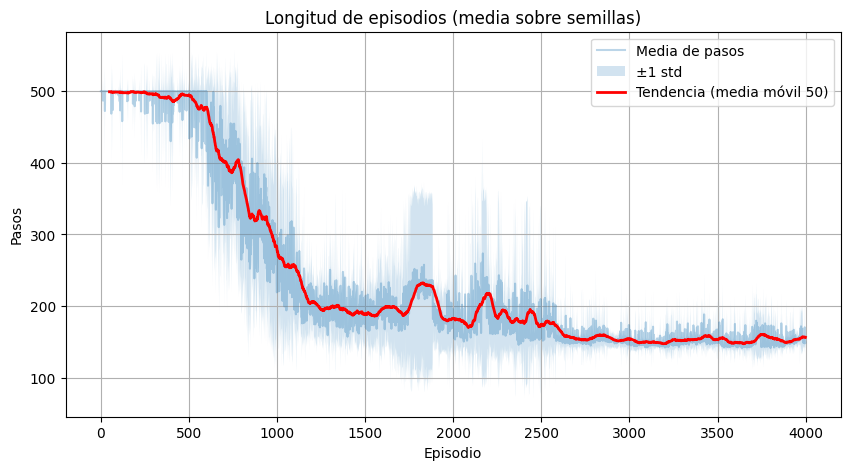

In [ ]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_2_500, std_longitudes_sarsa_2_500)

En este caso la longitud media de los episodios empieza a bajar bastante antes, alrededor del episodio 500, y la mejora se mantiene hasta el episodio 2500 aproximadamente. 

Al inicio hay más variabilidad entre semillas que diminuye sobre el episodio 2500, mostrando que los modelos tienden a estabilizarse en los 3000 pasos a una longitud por episodio menor a 200 pasos.

A su vez, se observa como las oscilaciones pequeñas de la media movil tienen una desviación más alta, por lo que estas curvas parecen deberse a semillas concretas.

#### **3.1.3. Máximo de 1000 pasos**

En primer lugar, se entrena el algoritmo

In [14]:
# @title Aprendizaje
media_longitudes_sarsa_2_1000, std_longitudes_sarsa_2_1000 = entrenar_agente(tcenv_2_1000)

 10%|█         | 415/4000 [00:09<00:40, 88.18it/s]

Episode: 400, Avg Return: -729.94, Epsilon: 0.400, Alpha: 0.157


 21%|██        | 836/4000 [00:12<00:19, 160.34it/s]

Episode: 800, Avg Return: -489.15, Epsilon: 0.250, Alpha: 0.063


 31%|███       | 1228/4000 [00:14<00:16, 172.58it/s]

...

 82%|████████▏ | 3269/4000 [00:27<00:03, 212.48it/s]

Episode: 3200, Avg Return: -269.30, Epsilon: 0.062, Alpha: 0.169


 91%|█████████ | 3623/4000 [00:29<00:02, 180.65it/s]

Episode: 3600, Avg Return: -259.06, Epsilon: 0.056, Alpha: 0.017


100%|██████████| 4000/4000 [00:32<00:00, 124.88it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

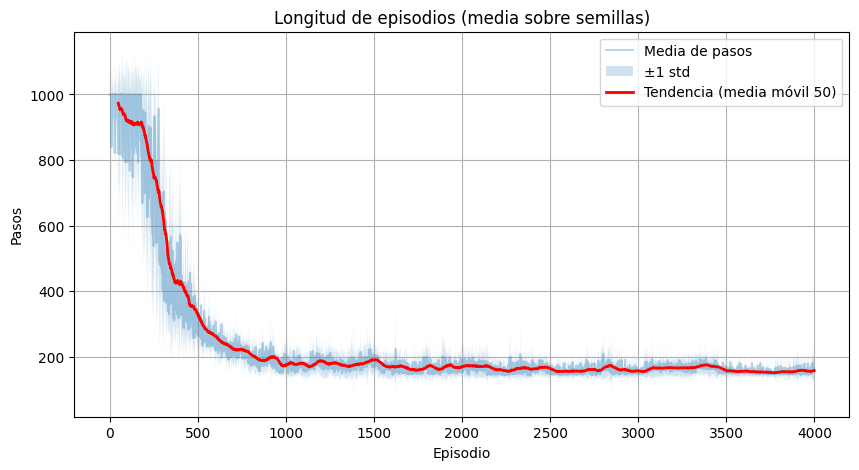

In [15]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_2_1000, std_longitudes_sarsa_2_1000)

Para un máximo de 1000 pasos, la longitud media de los episodios comienza a bajar desde el inicio. Esto se debe a que, con más número de pasos por episodio, resulta más sencillo lograr que se llegue a la meta por primera vez, y empiece a aprender.

Esta fase de mejora rápida termina sobre el episodio 1000, donde la media se estabiliza en un poco menos de 200 pasos.

Por último, se vuelve a observar una desviación típica que disminuye conforme los episodios avanzan.

### **3.2 Espacio discretizado con 4 tilings**

A continuación, se ejecutan los agentes utilizando 4 tilings.

#### **3.2.1. Máximo de 200 pasos**

En primer lugar, se entrena el algoritmo

In [16]:
# @title Aprendizaje
media_longitudes_sarsa_4_200, std_longitudes_sarsa_4_200 = entrenar_agente(tcenv_4_200)

 10%|█         | 415/4000 [00:03<00:30, 116.48it/s]

Episode: 400, Avg Return: -200.00, Epsilon: 0.400, Alpha: 1.000


 20%|██        | 819/4000 [00:06<00:27, 116.62it/s]

Episode: 800, Avg Return: -200.00, Epsilon: 0.250, Alpha: 1.000


 30%|███       | 1213/4000 [00:10<00:24, 114.29it/s]

...

 81%|████████  | 3231/4000 [00:26<00:05, 148.16it/s]

Episode: 3200, Avg Return: -183.57, Epsilon: 0.062, Alpha: 0.418


 91%|█████████ | 3632/4000 [00:29<00:02, 153.51it/s]

Episode: 3600, Avg Return: -180.03, Epsilon: 0.056, Alpha: 1.000


100%|██████████| 4000/4000 [00:32<00:00, 124.83it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

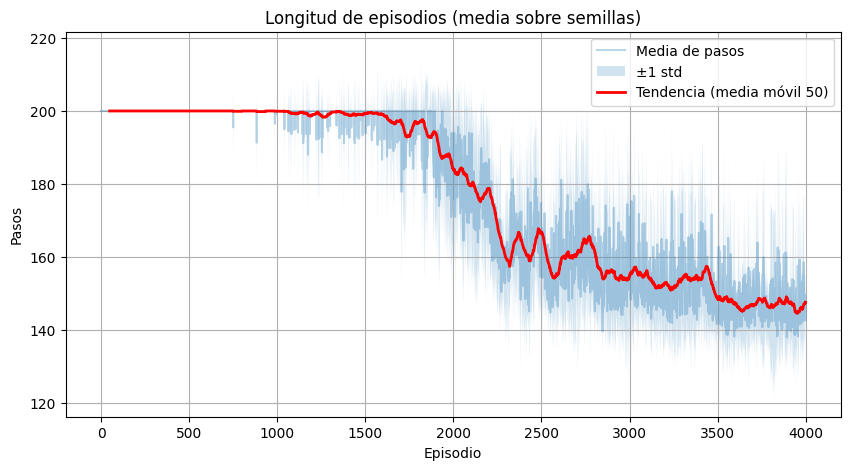

In [17]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_4_200, std_longitudes_sarsa_4_200)

Al inicio del entrenamiento, la longitud media de los episodios se mantiene pegada al límite de 200 pasos.

A partir del episodio 1500 aproximadamente, la tendencia empieza a descender, hasta llegar por debajo de los 180 pasos. Hay variación entre semillas, pero esta disminuye con el número de episodios.

#### **3.2.2. Máximo de 500 pasos**

En primer lugar, se entrena el algoritmo

In [18]:
# @title Aprendizaje
media_longitudes_sarsa_4_500, std_longitudes_sarsa_4_500 = entrenar_agente(tcenv_4_500)

 10%|█         | 408/4000 [00:08<01:08, 52.60it/s]

Episode: 400, Avg Return: -487.17, Epsilon: 0.400, Alpha: 0.331


 20%|██        | 817/4000 [00:13<00:30, 104.12it/s]

Episode: 800, Avg Return: -397.25, Epsilon: 0.250, Alpha: 0.518


 31%|███       | 1222/4000 [00:16<00:20, 137.58it/s]

...

 81%|████████  | 3222/4000 [00:34<00:05, 140.28it/s]

Episode: 3200, Avg Return: -246.05, Epsilon: 0.062, Alpha: 0.042


 91%|█████████ | 3628/4000 [00:37<00:02, 148.02it/s]

Episode: 3600, Avg Return: -236.12, Epsilon: 0.056, Alpha: 0.092


100%|██████████| 4000/4000 [00:40<00:00, 99.65it/s] 


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

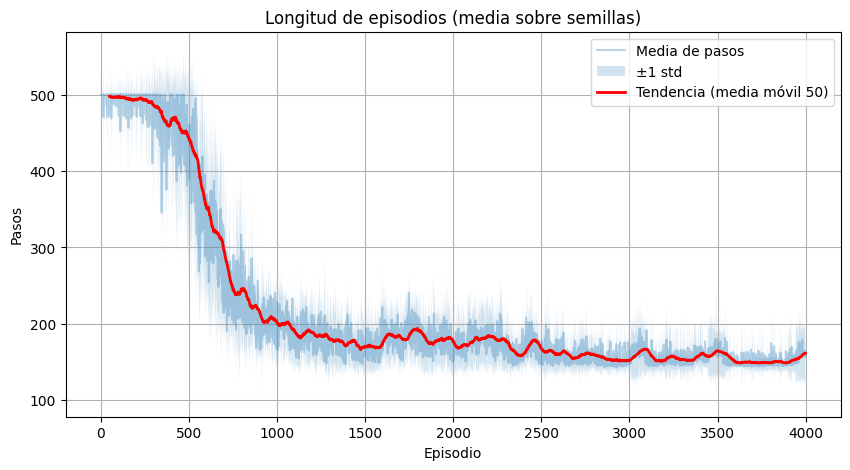

In [19]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_4_500, std_longitudes_sarsa_4_500)

La longitud media de los episodios empieza a bajar al inicio, y la mejora se mantiene hasta el episodio 1500 aproximadamente. 

Al inicio hay más variabilidad entre semillas que diminuye conforme avanzan los episodios. La longitud de pasos por episodio termina por debajo de los 200 pasos.

#### **3.2.3. Máximo de 1000 pasos**

En primer lugar, se entrena el algoritmo

In [20]:
# @title Aprendizaje
media_longitudes_sarsa_4_1000, std_longitudes_sarsa_4_1000 = entrenar_agente(tcenv_4_1000)

 10%|█         | 409/4000 [00:10<00:47, 75.87it/s]

Episode: 400, Avg Return: -625.44, Epsilon: 0.400, Alpha: 0.149


 21%|██        | 829/4000 [00:15<00:26, 120.62it/s]

Episode: 800, Avg Return: -436.66, Epsilon: 0.250, Alpha: 0.365


 31%|███       | 1223/4000 [00:18<00:20, 134.20it/s]

...

 81%|████████  | 3227/4000 [00:30<00:05, 146.22it/s]

Episode: 3200, Avg Return: -222.48, Epsilon: 0.062, Alpha: 0.188


 91%|█████████ | 3623/4000 [00:33<00:02, 146.24it/s]

Episode: 3600, Avg Return: -213.90, Epsilon: 0.056, Alpha: 0.055


100%|██████████| 4000/4000 [00:36<00:00, 111.07it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

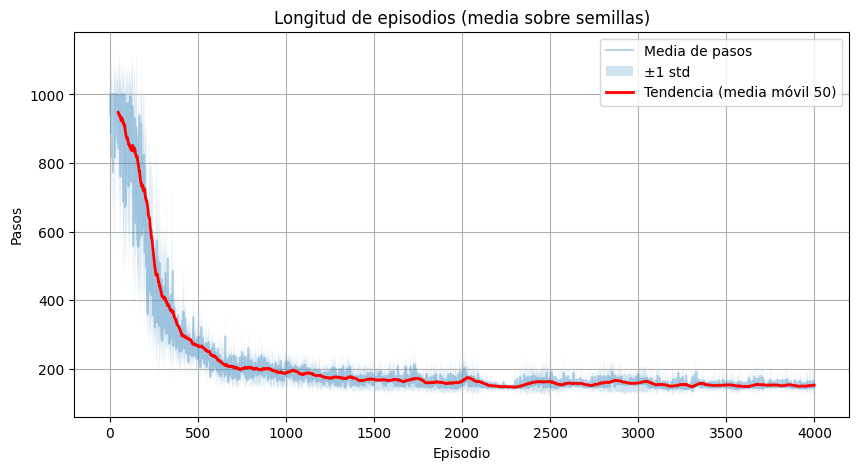

In [21]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_4_1000, std_longitudes_sarsa_4_1000)

La longitud media de los episodios comienza a bajar desde el inicio. Esta fase de mejora rápida termina alrededor el episodio 750, donde la media se estabiliza en algo menos de 200 pasos.

Por último, se vuelve a observar una desviación típica que disminuye conforme los episodios avanzan.

### **3.3 Espacio discretizado con 10 tilings**

#### **3.3.1. Máximo de 200 pasos**

En primer lugar, se entrena el algoritmo

In [22]:
# @title Aprendizaje
media_longitudes_sarsa_10_200, std_longitudes_sarsa_10_200 = entrenar_agente(tcenv_10_200)

 10%|█         | 413/4000 [00:06<00:55, 64.45it/s]

Episode: 400, Avg Return: -200.00, Epsilon: 0.400, Alpha: 0.568


 20%|██        | 812/4000 [00:12<00:50, 63.37it/s]

Episode: 800, Avg Return: -200.00, Epsilon: 0.250, Alpha: 1.000


 30%|███       | 1211/4000 [00:19<00:44, 62.21it/s]

...

 80%|████████  | 3214/4000 [00:46<00:10, 73.69it/s]

Episode: 3200, Avg Return: -177.51, Epsilon: 0.062, Alpha: 1.000


 90%|█████████ | 3609/4000 [00:51<00:04, 84.44it/s]

Episode: 3600, Avg Return: -174.29, Epsilon: 0.056, Alpha: 0.820


100%|██████████| 4000/4000 [00:55<00:00, 71.48it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

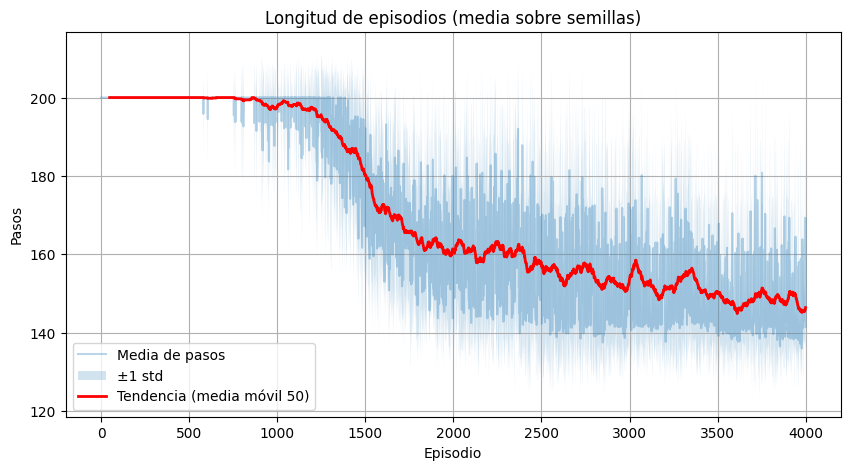

In [23]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_10_200, std_longitudes_sarsa_10_200)

Al inicio del entrenamiento, la longitud media de los episodios se mantiene pegada al límite de 200 pasos.

A partir del episodio 1000 aproximadamente, la tendencia empieza a descender, hasta situarse por debajo de los 160 pasos al final del entrenamiento. Hay una variación importante entre semillas, pero incluso teniendo en cuenta la desviación típica la mayoría de episodios terminan por debajo de los 200 pasos.

#### **3.3.2. Máximo de 500 pasos**

En primer lugar, se entrena el algoritmo

In [24]:
# @title Aprendizaje
media_longitudes_sarsa_10_500, std_longitudes_sarsa_10_500 = entrenar_agente(tcenv_10_500)

 10%|█         | 407/4000 [00:14<01:34, 38.03it/s]

Episode: 400, Avg Return: -462.81, Epsilon: 0.400, Alpha: 1.000


 20%|██        | 808/4000 [00:22<00:47, 67.53it/s]

Episode: 800, Avg Return: -357.17, Epsilon: 0.250, Alpha: 1.000


 30%|███       | 1209/4000 [00:28<00:48, 57.12it/s]

...

 80%|████████  | 3209/4000 [00:58<00:09, 79.53it/s]

Episode: 3200, Avg Return: -217.19, Epsilon: 0.062, Alpha: 0.667


 90%|█████████ | 3610/4000 [01:03<00:04, 84.42it/s]

Episode: 3600, Avg Return: -209.25, Epsilon: 0.056, Alpha: 0.637


100%|██████████| 4000/4000 [01:08<00:00, 58.41it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

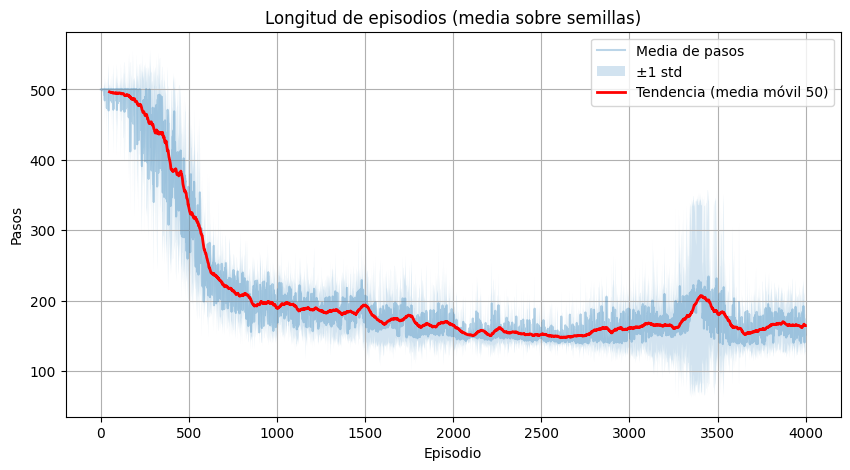

In [25]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_10_500, std_longitudes_sarsa_10_500)

La longitud media de los episodios empieza a bajar al inicio, y la bajada rápida se mantiene hasta el episodio 1000 aproximadamente. 

Al inicio hay más variabilidad entre semillas que disminuye conforme avanzan los episodios. Se observa una oscilación en la media movil entre el episodio 3000 y 3500, que tiene una desviación notablemente más alta,  lo que sugiere que ese pico se debe a semillas concretas

La media de longitud de los episodios se estabiliza por debajo de los 200 pasos.

#### **3.3.3. Máximo de 1000 pasos**

En primer lugar, se entrena el algoritmo

In [26]:
# @title Aprendizaje
media_longitudes_sarsa_10_1000, std_longitudes_sarsa_10_1000 = entrenar_agente(tcenv_10_1000)

 10%|█         | 409/4000 [00:15<01:15, 47.82it/s]

Episode: 400, Avg Return: -488.13, Epsilon: 0.400, Alpha: 1.000


 20%|██        | 808/4000 [00:23<00:54, 58.41it/s]

Episode: 800, Avg Return: -355.94, Epsilon: 0.250, Alpha: 1.000


 30%|███       | 1205/4000 [00:30<00:45, 61.35it/s]

...

 80%|████████  | 3209/4000 [00:58<00:09, 80.77it/s]

Episode: 3200, Avg Return: -210.69, Epsilon: 0.062, Alpha: 0.043


 90%|█████████ | 3612/4000 [01:03<00:05, 75.53it/s]

Episode: 3600, Avg Return: -203.25, Epsilon: 0.056, Alpha: 0.588


100%|██████████| 4000/4000 [01:08<00:00, 58.07it/s]


Una vez entrenado, se muestra la media y desviación típica de la longitud de los episodios

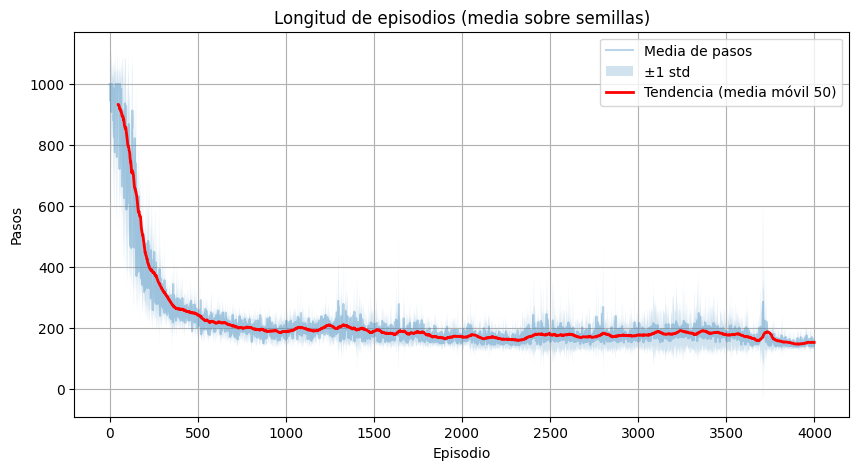

In [27]:
#@title Media y desviación típica de la longitud de los episodios
plot_lengths_mean_std(media_longitudes_sarsa_10_1000, std_longitudes_sarsa_10_1000)

La longitud media de los episodios comienza a bajar desde el inicio. Esta fase de mejora rápida termina alrededor del episodio 500, donde la media se estabiliza en algo menos de 200 pasos.

### **3.4. Comparar resultados**

Una vez han finalizado los experimentos, se comparan los resultados para decidir tanto el mejor número de tilings como el mejor número máximo de pasos.

Para ello, se guardan en una variable `results` los resultados de los experimentos, es decir, la media para las semillas de los pasos por episodio en cada configuración (número de tilings y número máximo de pasos).

In [28]:
results = {
    (2, 200):  media_longitudes_sarsa_2_200,
    (2, 500):  media_longitudes_sarsa_2_500,
    (2, 1000): media_longitudes_sarsa_2_1000,
    (4, 200):  media_longitudes_sarsa_4_200,
    (4, 500):  media_longitudes_sarsa_4_500,
    (4, 1000): media_longitudes_sarsa_4_1000,
    (10, 200): media_longitudes_sarsa_10_200,
    (10, 500): media_longitudes_sarsa_10_500,
    (10, 1000): media_longitudes_sarsa_10_1000,
}


A continuación, se declaran funciones para comparar de forma más clara las configuraciones.

In [ ]:
def suavizar(datos, window_size=50):
    # No se puede hacer la media movil si el tamaño de media movil es mayor al número de puntos
    if len(datos) < window_size:
        return datos
    # Devuelve la media movil de los datos
    return np.convolve(datos, np.ones(window_size)/window_size, mode='valid')

def plot_tilings_fijo_steps(results, max_steps, tilings_list=(2, 4, 10), window_size=50):
    # Crea una figura
    plt.figure(figsize=(10, 5))
    # Asigna colores a cada número de tilings
    colores = {2: 'tab:blue', 4: 'tab:orange', 10: 'tab:green'}
    # Por cada número de tilings, los dibuja
    for til in tilings_list:
        # Obtiene su media
        mean_episode_lengths = results[(til, max_steps)]
        # Calcula la media movil
        curva_suav = suavizar(mean_episode_lengths, window_size)
        # Pinta los puntos
        x = np.arange(len(curva_suav))
        plt.plot(x, curva_suav, color=colores[til], label=f'{til} tilings')
    # Muestra los títulos
    plt.title(f'Longitud media de episodios (max_steps={max_steps})')
    plt.xlabel('Episodio')
    plt.ylabel('Pasos (media suavizada)')
    # Muestra la gráfica
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_steps_fijo_tilings(results, tilings, steps_list=(200, 500, 1000), window_size=50):
    # Crea una figura
    plt.figure(figsize=(10, 5))
    # Asigna colores a cada número de pasos máximos
    colores = {200: 'tab:blue', 500: 'tab:orange', 1000: 'tab:green'}
    # Por cada número de pasos máximo, los dibuja
    for ms in steps_list:
        # Obtiene su media
        mean_episode_lengths = results[(tilings, ms)]
        # Calcula la media movil
        curva_suav = suavizar(mean_episode_lengths, window_size)
        # Pinta los puntos
        x = np.arange(len(curva_suav))
        plt.plot(x, curva_suav, color=colores[ms], label=f'max_steps={ms}')
    # Muestra los títulos
    plt.title(f'Longitud media de episodios ({tilings} tilings)')
    plt.xlabel('Episodio')
    plt.ylabel('Pasos (media suavizada)')
    # Muestra la gráfica
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#### **3.4.1. Comparar tilings**

Se muestra la gráfica del número de tilings para un máximo de 200 pasos por episodio. En cada curva se representa la media móvil de la longitud media de los episodios para las distintas semillas, para que la comparación entre tilings sea más clara.

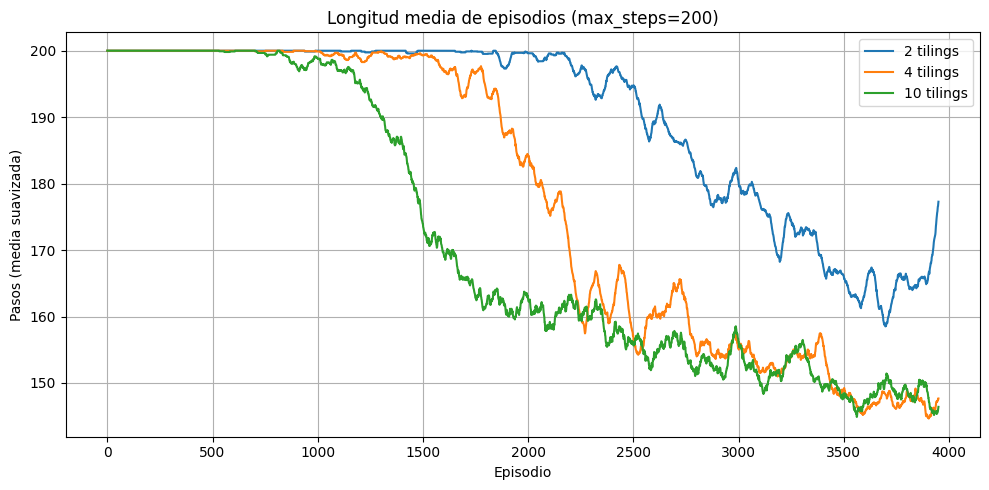

In [30]:
plot_tilings_fijo_steps(results, max_steps=200)

Las tres configuraciones comienzan pegadas a los 200 pasos máximos. La configuración con 10 tilings es la que antes comienza a descender, seguida de la de 4 tilings. A partir de unos 2500 episodios, estas dos curvas se vuelven bastante similares. 

Sine embargo, la configuración con 2 tilings comienza a descender más tarde y termina con un número de pasos más elevado.

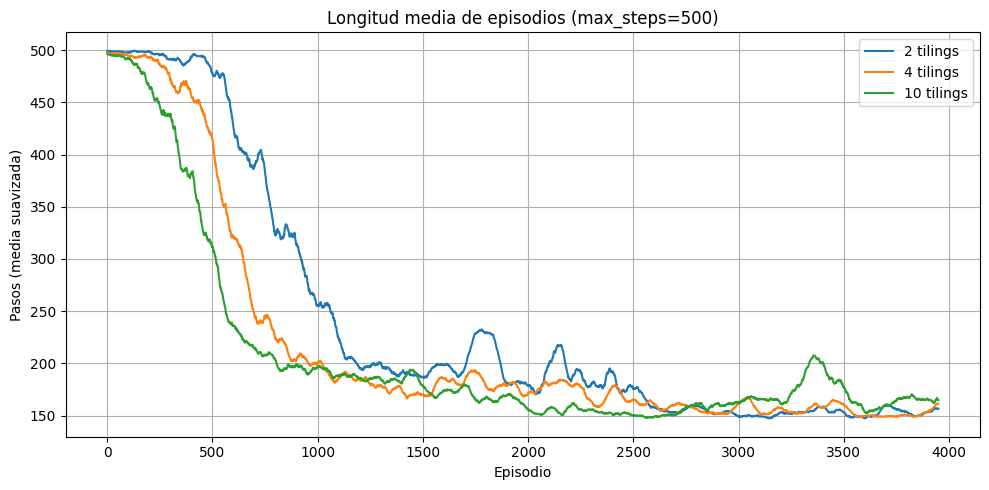

In [31]:
plot_tilings_fijo_steps(results, max_steps=500)

Las tres configuraciones empiezan a descender casi desde el inicio de la gráfica. Cuantos más tilings se utilizan, antes comienza esa bajada, aunque al final las curvas terminan siendo muy similares. Se observan ciertas oscilaciones, probablemente debidas a que los resultados se han obtenido con solo 6 semillas. Es de esperar que con más semillas estas desviaciones disminuyeran.

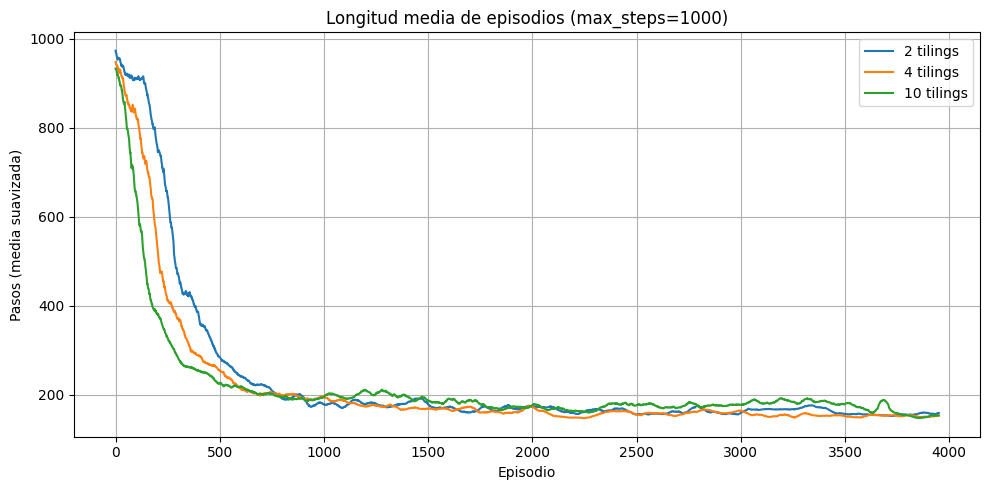

In [32]:
plot_tilings_fijo_steps(results, max_steps=1000)

Para 1000 pasos se vuelve a observar que la configuración con 10 tilings es la que antes comienza a descender, seguida de la de 4 tilings y, por último, la de 2 tilings. A partir de unos 1000 episodios, las tres curvas son muy similares entre sí.

#### **3.4.2. Comparar máximo de pasos**

Una vez analizado el efecto del número de tilings, se estudia cómo el máximo número de pasos por episodio influye en la velocidad del aprendizaje y la convergencia a una política cercana a la óptima.

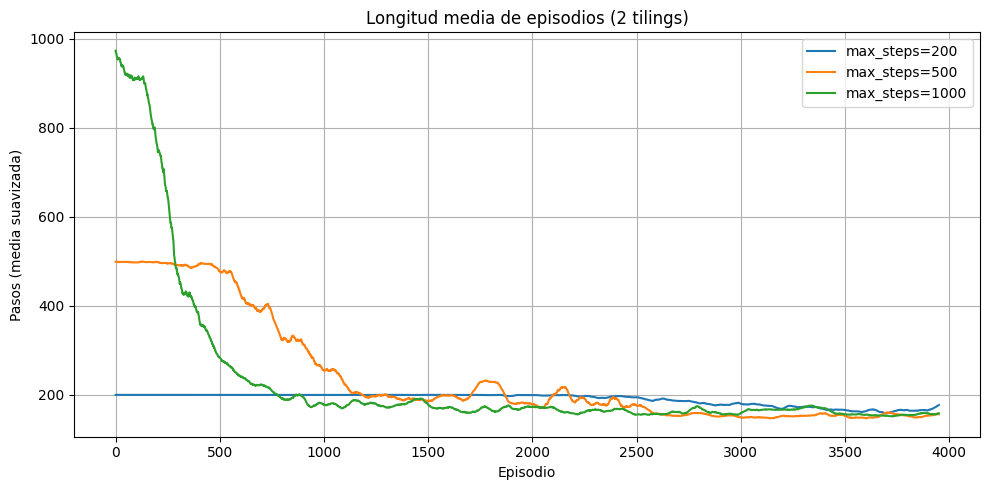

In [33]:
plot_steps_fijo_tilings(results, tilings=2)

Para 2 tilings, se observa como la configuración con un máximo de 1000 pasos es la que antes mejora, siendo la primera en conseguir un número de pasos medios por debajo de 200. A continuación, la configuración con un máximo de 500 pasos también muestra una mejora rápida. 

La configuración de 200 pasos tarda algo más en descender. Sin embargo, a partir de 3500 episodios la media móvil de pasos de las 3 configuraciones se vuelve similar.

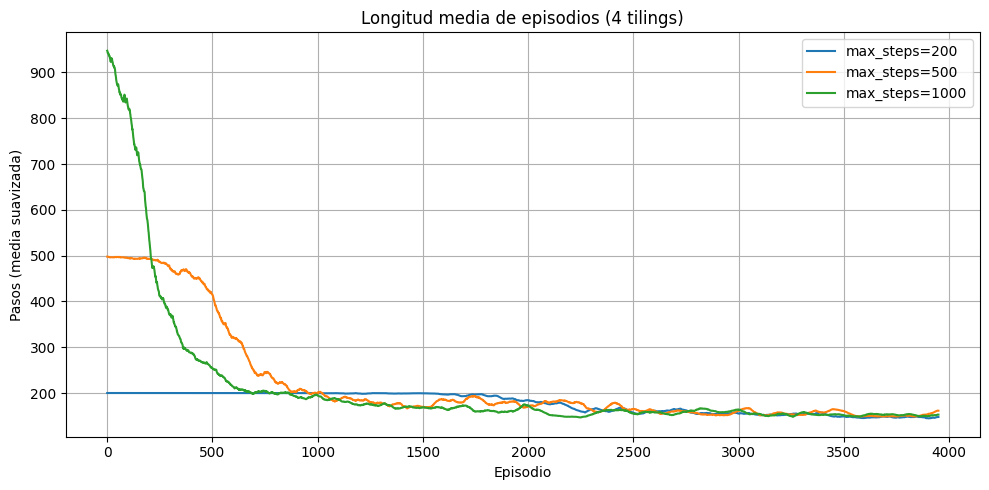

In [34]:
plot_steps_fijo_tilings(results, tilings=4)

Para 4 tilings, se vuelve a observar una mejora más rápida cuanto mayor es el número de pasos máximos por episodio. Además, a partir de unos 2500 episodios las tres configuraciones se vuelven muy similares.

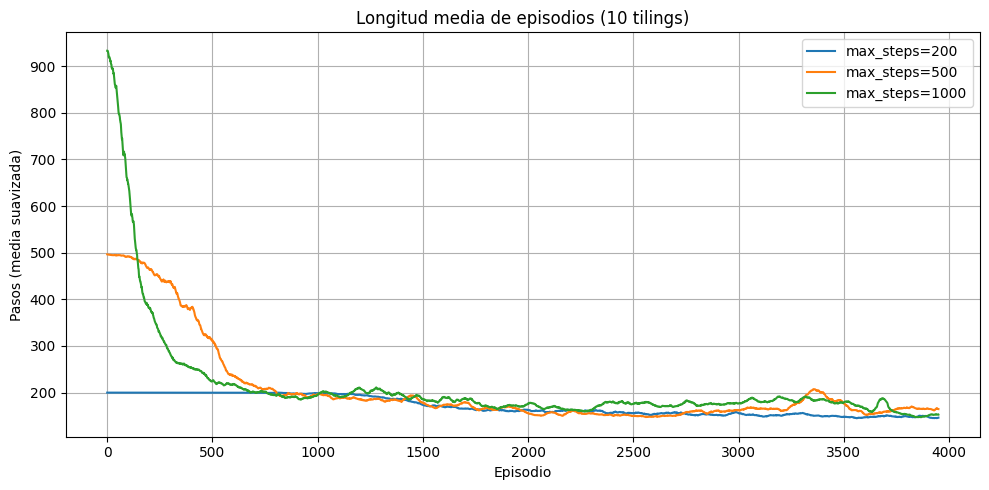

In [35]:
plot_steps_fijo_tilings(results, tilings=10)

Por último, para 10 tilings, se vuelve a observar una mejora más rápida cuanto mayor es el número de pasos máximos por episodio. El rendimiento de las 3 configuraciones se vuelve similar a partir de aproximadamente 1000 episodios, observándose un órden estre estas que fluctúa, lo que probablemente se deba a la varianza introducida por usar únicamente 6 semillas distintas. Se espera que, con un mayor número de semillas, estas diferencias se reduzcan.

## **4. Conclusiones**

Como conclusiones, tanto el número de tilings como el número máximo de pasos por episodio influyen principalmente en las fases iniciales del aprendizaje. A medida que este avanza, las diferencias entre configuraciones tienden a desaparecer.

Respecto al número de pasos máximos por episodio, si se busca una convergencia en un menor número de episodios, se recomienda permitir un mayor número de pasos, mientras que si se va a entrenar durante más episodios es suficiente con un límite menor. Debe tenerse en cuenta que un mayor número de pasos máximos también supone que en los episodios iniciales se ejecuten muchos más pasos por episodio.

Respecto al número de tilings, si se busca una convergencia más rápida se recomienda utilizar un mayor número de tilings, mientras que si se va a entrenar durante más episodios el rendimiento con 2, 4, y 10 tilings es similar a largo plazo. Por lo tanto, se debe tener en cuenta el número de episodios a realizar para escoger el número de tilings óptimo. También es importante tener en cuenta que más tilings suponen un mayor número de parámetros del agente almacenados en memoria.